In [ ]:
import pandas as pd
df = pd.read_excel('/content/employee_productivity_dataset.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EmployeeID            550 non-null    object
 1   Department            550 non-null    object
 2   Gender                550 non-null    object
 3   RemotePreference      550 non-null    object
 4   WeeklyHours           550 non-null    int64 
 5   OvertimeFreq          550 non-null    object
 6   ToolProficiency       550 non-null    object
 7   JobSatisfactionLevel  540 non-null    object
 8   YearsExperience       550 non-null    int64 
 9   ProductivityScore     550 non-null    int64 
dtypes: int64(3), object(7)
memory usage: 43.1+ KB


In [ ]:
summary_table = df.groupby('RemotePreference').agg({
    'RemotePreference': 'count',
    'ProductivityScore': 'mean',
    'WeeklyHours': 'mean'
}).rename(columns={'RemotePreference': 'Employee Count'})

print(summary_table)

                  Employee Count  ProductivityScore  WeeklyHours
RemotePreference                                                
Hybrid                       171          59.573099    41.251462
Office                       217          54.792627    41.110599
Remote                       162          59.209877    40.876543


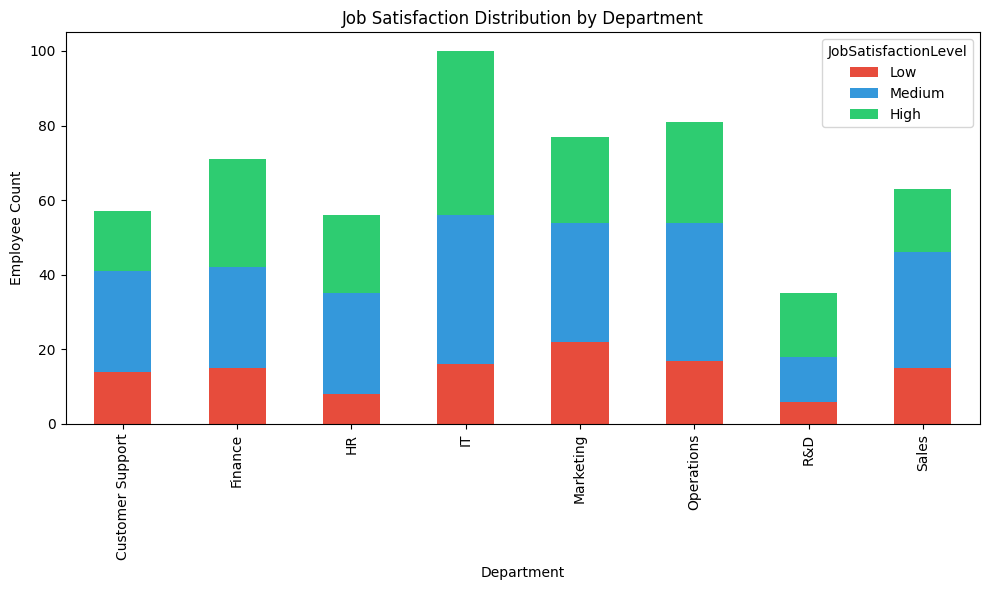

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cross-tabulate to count satisfaction levels per department
dept_satisfaction = pd.crosstab(df['Department'], df['JobSatisfactionLevel'])

# Plotting
dept_satisfaction[['Low', 'Medium', 'High']].plot(kind='bar',
                                                stacked=True,
                                                figsize=(10, 6),
                                                color=['#e74c3c', '#3498db', '#2ecc71'])

plt.title('Job Satisfaction Distribution by Department')
plt.ylabel('Employee Count')
plt.tight_layout()
plt.show()

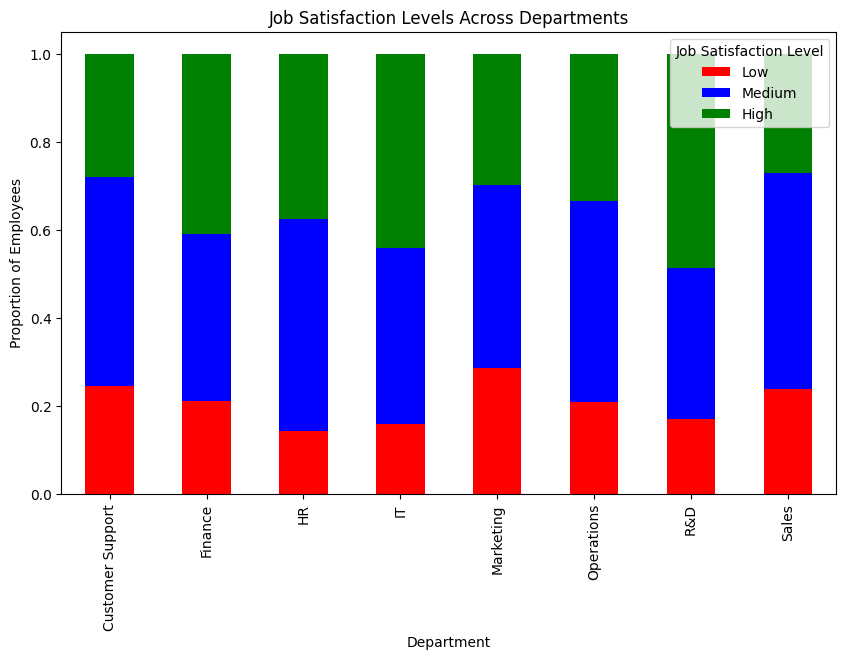

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


dept_satisfaction = pd.crosstab(
    df['Department'],
    df['JobSatisfactionLevel'],
    normalize='index'
)

dept_satisfaction = dept_satisfaction[['Low', 'Medium', 'High']]


dept_satisfaction.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['red', 'blue', 'green']
)
plt.xlabel('Department')
plt.ylabel('Proportion of Employees')
plt.title('Job Satisfaction Levels Across Departments')
plt.legend(title='Job Satisfaction Level')
plt.show()

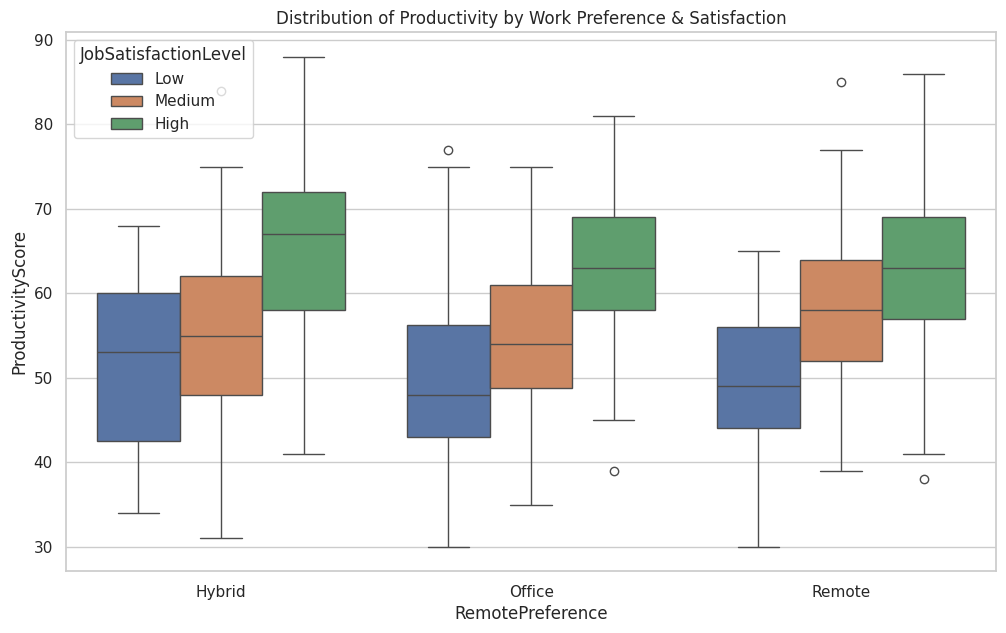

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
ax = sns.boxplot(data=df,
                 x='RemotePreference',
                 y='ProductivityScore',
                 hue='JobSatisfactionLevel')
plt.title('Distribution of Productivity by Work Preference & Satisfaction')
plt.show()

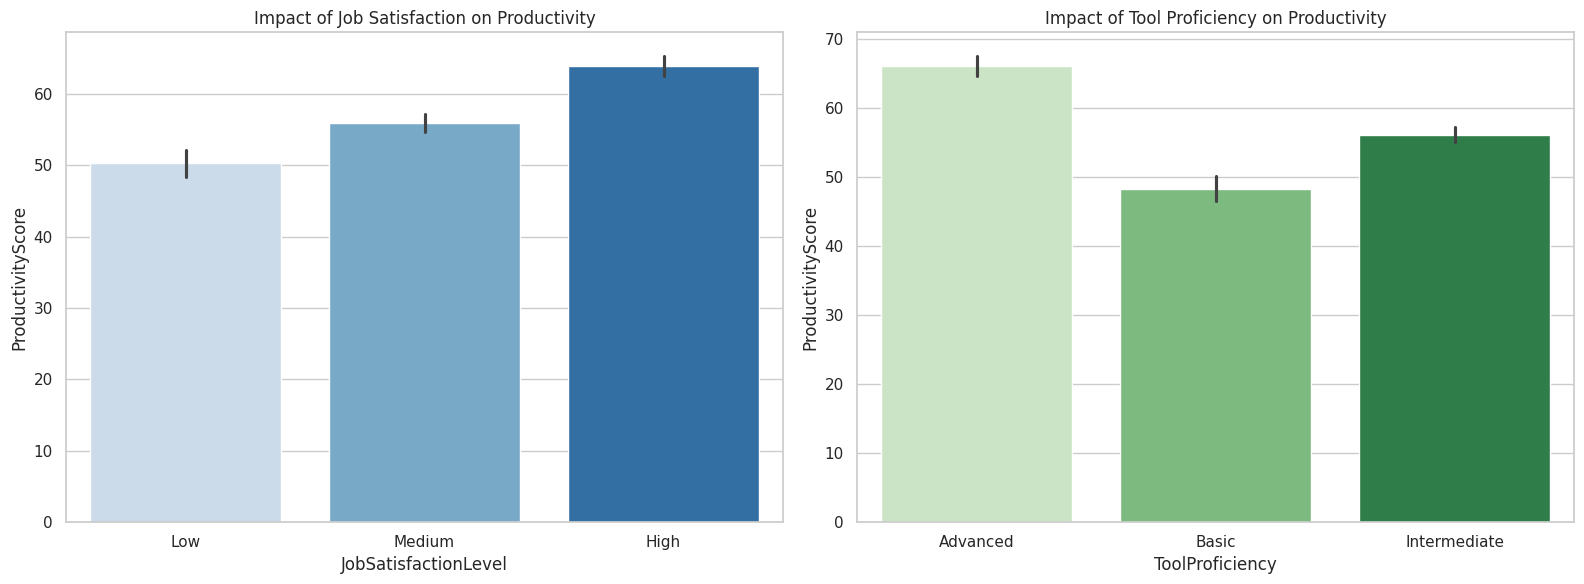

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot (a): Job Satisfaction
sns.barplot(data=df, x='JobSatisfactionLevel', y='ProductivityScore', ax=axes[0], palette='Blues', hue='JobSatisfactionLevel', legend=False)
axes[0].set_title('Impact of Job Satisfaction on Productivity')

# Plot (b): Tool Proficiency
sns.barplot(data=df, x='ToolProficiency', y='ProductivityScore', ax=axes[1], palette='Greens', hue='ToolProficiency', legend=False)
axes[1].set_title('Impact of Tool Proficiency on Productivity')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Create the interactive scatter plot
fig = px.scatter(df,
                 x='YearsExperience',
                 y='ProductivityScore',
                 color='RemotePreference',
                 hover_data=['Department', 'JobSatisfactionLevel'], # Interactive feature: Hover Info
                 title='Experience vs. Productivity by Work Preference')

fig.show()